# Imports

In [200]:
import torch
import torch.nn as nn

import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt

# Dataset

Dog

 ↓

Predict

 ↓

Car

- is nonsense 

but this

Original Image

- View 1:

    - Crop, Flip

- View 2:

    - Crop, Color Jitter

In [201]:
# change 1, from v2
augmentation = transforms.Compose([
    transforms.RandomResizedCrop(32),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),

    transforms.ToTensor()
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
)

# Get Images

In [202]:
image, _ = dataset[0]

# Generate two views

In [203]:
view1 = augmentation(image)
view2 = augmentation(image)

[]

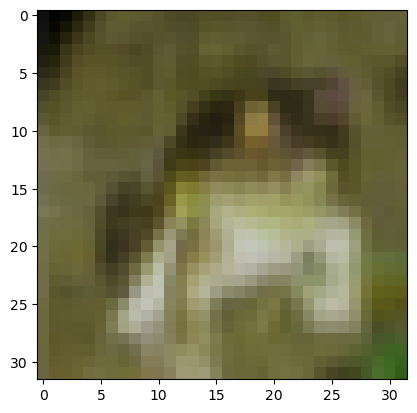

In [204]:
plt.imshow(view1.permute(1, 2, 0))
plt.plot()

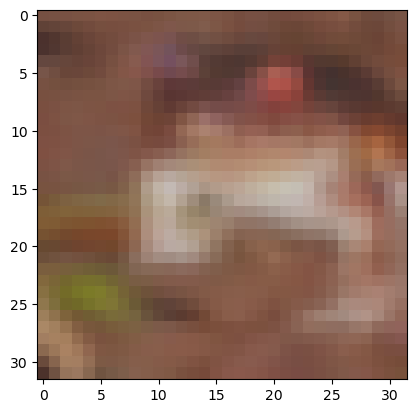

In [205]:
plt.imshow(view2.permute(1, 2, 0))

# Add batch Dim

In [206]:
view1 = view1.unsqueeze(0)
view2 = view2.unsqueeze(0)

# Encoder

In [207]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(
                32 * 8 * 8,
                128
            )
        )

    def forward(self, x):
        return self.encoder(x)

# Predictor

In [208]:
class Predictor(nn.Module):

    def __init__(self):
        super().__init__()

        self.predictor = nn.Sequential(

            nn.Linear(128, 256),

            nn.ReLU(),

            nn.Linear(256, 128)
        )

    def forward(self, x):
        return self.predictor(x)

# Create Models

In [209]:
online_encoder = Encoder()

target_encoder = Encoder()

predictor = Predictor()

# Copy Weights

In [210]:
target_encoder.load_state_dict(
    online_encoder.state_dict()
)

<All keys matched successfully>

# Freeze Target Encoder

In [211]:
for param in target_encoder.parameters():
    param.requires_grad = False

# Loss Function

In [212]:
loss_fn = nn.MSELoss()

# Optimizer

In [213]:
optimizer = torch.optim.Adam(
    list(online_encoder.parameters()) +
    list(predictor.parameters()),
    lr=0.001
)

# Forward Pass

### Online side

In [214]:
z1 = online_encoder(view1)

pred_z2 = predictor(z1)

### Target side

In [215]:
with torch.no_grad():

    z2 = target_encoder(view2)

In [216]:
print(z1.shape)
print(pred_z2.shape)
print(z2.shape)

torch.Size([1, 128])
torch.Size([1, 128])
torch.Size([1, 128])


# Compute Loss

In [217]:
loss = loss_fn(
    pred_z2,
    z2
)

print(loss)

tensor(0.0088, grad_fn=<MseLossBackward0>)


# Backpropagation

In [218]:
optimizer.zero_grad()
loss.backward()
optimizer.step()

Online Encoder  ✓ updated

Predictor       ✓ updated

Target Encoder  ✗ unchanged

# EMA Update

In [219]:
m = 0.99

for target_param, online_param in zip(
    target_encoder.parameters(),
    online_encoder.parameters()
):

    target_param.data = (
        m * target_param.data
        +
        (1 - m) * online_param.data
    )

# Full Architecture

image 1 -> online Encoder -> z1 -> predictor -> pred_z2

image 2 -> target Encoder -> z2

MSE loss

# Training Loop

In [220]:
for epoch in range(100):
    
    view1 = augmentation(image)
    view2 = augmentation(image)

    view1 = view1.unsqueeze(0)
    view2 = view2.unsqueeze(0)

    # find pred z2 using z1
    z1 = online_encoder(view1)
    pred_z2 = predictor(z1)

    # find actual z2
    with torch.no_grad():
        z2 = target_encoder(view2)
    
    # find loss
    # loss = loss_fn(z2, pred_z2)

    # real BYOL uses cosine similarity
    loss = 1 - F.cosine_similarity(
    pred_z2,
    z2,
    dim=1
    ).mean()

    # This update online_encoder
    optimizer.zero_grad() # Clear the old math.
    loss.backward() # This function performs the actual backpropagation, but it only does the math.
    optimizer.step() # This is where the actual updating happens.

    # update target_encoder
    for target_param, online_param in zip(
        target_encoder.parameters(),
        online_encoder.parameters()
    ):
        
        # formula to update target_encoder a small step
        # like .2 .2 .2
        target_param.data = (m * target_param) + ((1-m) * online_param)

    print(epoch, loss.item())



0 0.5791699886322021
1 0.358659565448761
2 0.250852108001709
3 0.17155563831329346
4 0.09465253353118896
5 0.07814359664916992
6 0.07625001668930054
7 0.09439361095428467
8 0.048238158226013184
9 0.07887625694274902
10 0.07228356599807739
11 0.05285632610321045
12 0.04757648706436157
13 0.04165041446685791
14 0.037132084369659424
15 0.06767839193344116
16 0.03646290302276611
17 0.03186476230621338
18 0.04886907339096069
19 0.02011805772781372
20 0.016941428184509277
21 0.01980888843536377
22 0.02335333824157715
23 0.020302414894104004
24 0.01020270586013794
25 0.01588726043701172
26 0.011577785015106201
27 0.012705445289611816
28 0.008781909942626953
29 0.007109999656677246
30 0.005713701248168945
31 0.012053251266479492
32 0.0036940574645996094
33 0.00579988956451416
34 0.00834798812866211
35 0.003992974758148193
36 0.004140794277191162
37 0.008711814880371094
38 0.003329336643218994
39 0.0022365450859069824
40 0.0030196309089660645
41 0.003960013389587402
42 0.001814723014831543
43 0

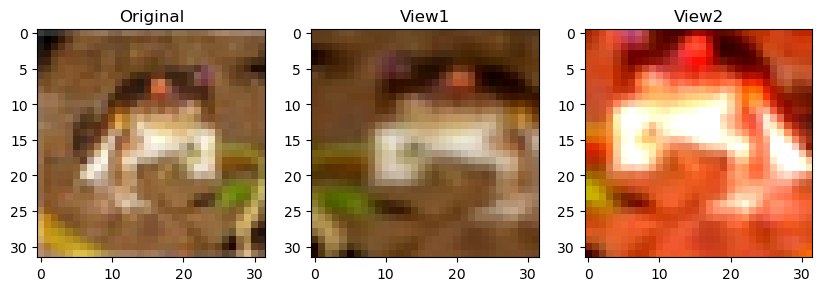

In [221]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(view1.squeeze(0).permute(1,2,0))
plt.title("View1")

plt.subplot(1,3,3)
plt.imshow(view2.squeeze(0).permute(1,2,0))
plt.title("View2")

plt.show()

In [222]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    z1,
    z2,
    dim=1
)

print(similarity)

tensor([0.9944], grad_fn=<SumBackward1>)
